#GSoC 2026 Preparation Work

##ASL MRI Exploration using NiBabel

**Author**: Harshita Sharma

## Objective

This notebook explores ASL MRI data using the NiBabel library.
The goal is to understand brain signal behaviour and potential
quality control metrics that may help identify imaging artifacts.

In [1]:
import nibabel as nib 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = nib.load("sub-RS001_ses-1_task-rest_bold.nii.gz")
data = img.get_fdata()

print(data.shape)


(64, 64, 36, 80)


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

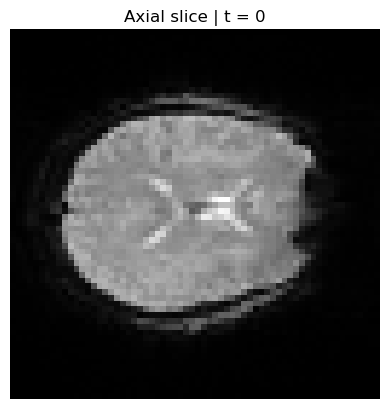

In [3]:
z = data.shape[2] // 2   # middle axial slice
t = 0                   # first time point

slice_img = data[:, :, z, t]

plt.imshow(slice_img, cmap="gray")
plt.title("Axial slice | t = 0")
plt.axis("off")


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

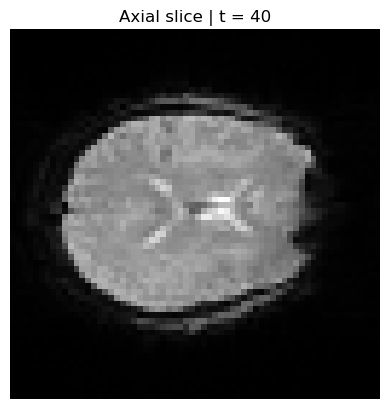

In [4]:
t = 40   # mid time point
slice_img = data[:, :, z, t]

plt.imshow(slice_img, cmap="gray")
plt.title("Axial slice | t = 40")
plt.axis("off")


Text(0.5, 1.0, 'Voxel signal over time')

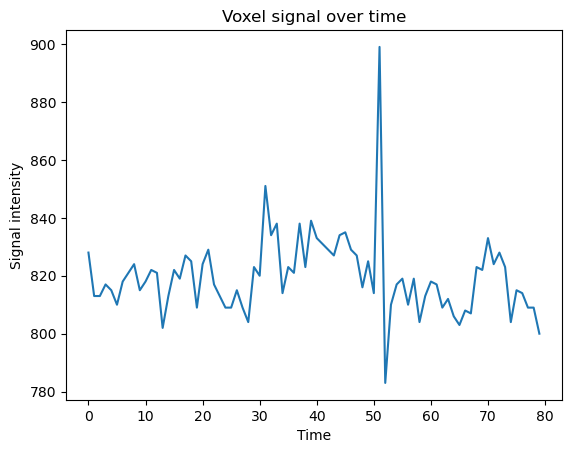

In [5]:
x, y, z = 32, 32, data.shape[2] // 2
voxel_signal = data[x, y, z, :]

plt.plot(voxel_signal)
plt.xlabel("Time")
plt.ylabel("Signal intensity")
plt.title("Voxel signal over time")


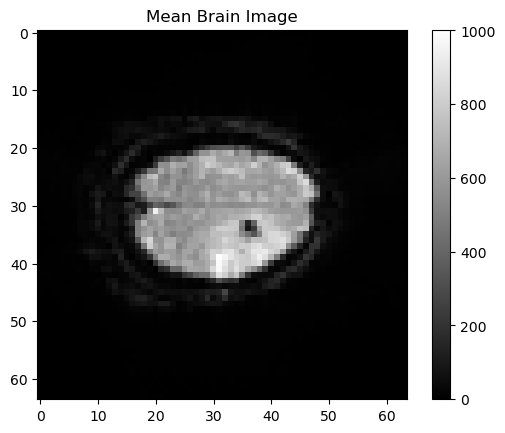

In [7]:
mean_brain = np.mean(data, axis=3)

plt.imshow(mean_brain[:, :, 30], cmap='gray')
plt.colorbar()
plt.title("Mean Brain Image")
plt.show()


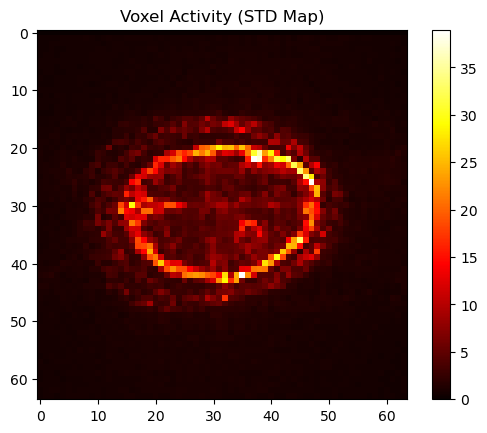

In [8]:
std_brain = np.std(data, axis=3)

plt.imshow(std_brain[:, :, 30], cmap='hot')
plt.colorbar()
plt.title("Voxel Activity (STD Map)")
plt.show()


In [10]:
print("Min value:", np.min(data))
print("Max value:", np.max(data))
print("Mean value:", np.mean(data))


Min value: 0.0
Max value: 1651.0
Mean value: 149.29816436767578
